In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as ss
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [2]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')

In [3]:
c = 3e8
# extract data
wl = data_rv['lambd']
rv = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days

In [4]:
# get only one month of data, to compare with observed data
n_days = 31
data_spectra = data_spectra[times < n_days]
rv = rv[times < n_days]
times = times[times < n_days]

In [5]:
wl.shape

(122,)

In [6]:
# mean spectrum
mean_spec = np.mean(data_spectra, axis=0)  # calculate mean spectrum (i.e. the mean flux for each wl)
# take out projection over the velocity vector
S_f, D = t.subtract_v(wl, data_spectra, c=3e8)  # speed of light in m/s

## Apply PCA

In [7]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(S_f)
# spectra_centered = S_f

In [8]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [9.94063088e-01 5.47581524e-03 3.94240924e-04 5.28687894e-05
 1.22878792e-05 1.07670271e-06 3.96556017e-07 1.23207290e-07
 5.61097069e-08 3.09369809e-08 4.18726296e-09 2.07820430e-09
 6.69311776e-10 6.42802734e-10 4.63360112e-10 4.47315863e-10
 4.21235160e-10 4.00372984e-10 3.93719996e-10 3.78562186e-10]


In [9]:
# save loadings and scores
loadings = pca_flux.components_
scores = np.array([pcs[:, i] for i in range(n_components)])

In [10]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
snr = 5e3
sigma = 1 / snr
mean_maxes = t.calculate_pca_significance(n_realizations, n_components, spectra_centered, sigma)  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

100%|██████████| 20/20 [00:00<00:00, 116.39it/s]


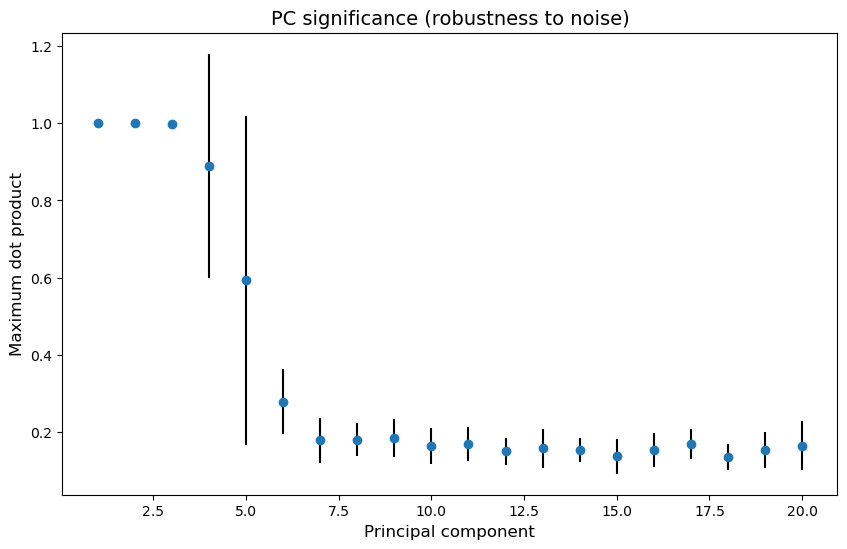

In [11]:
# plot component significance
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('PC significance (robustness to noise)', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [19]:
# calculate power spectrum
dt = times[1] - times[0]
sp = np.array([np.fft.fft(scores[i]) for i in range(n_components)])
freq = np.array([np.fft.fftfreq(scores[i].shape[0], dt) for i in range(n_components)])
power = np.abs(sp)**2

In [20]:
sp.shape

(20, 310)

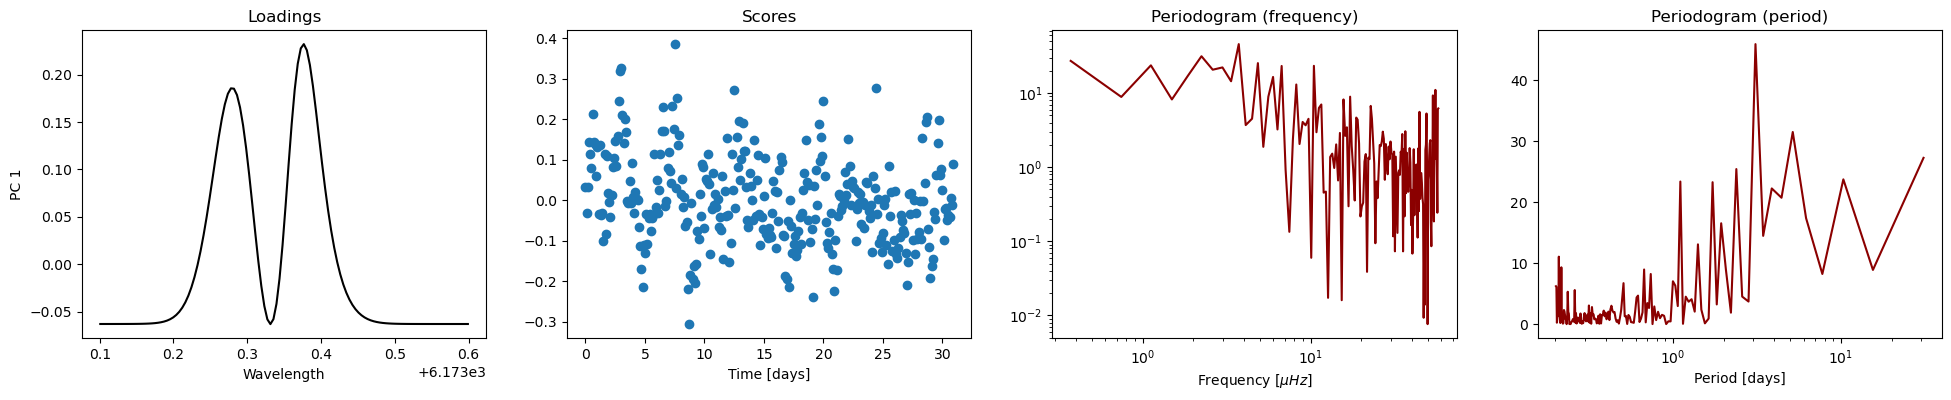

In [21]:
# plot
for i in range(1):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, loadings[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, scores[i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] / 86400 * 10**6, power[i][mask], color='darkred')  # frequency divided by 86400 to pass from days^-1 to Hz, then multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram (frequency)', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')

    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram (period)', size=12)
    axs[3].set_xlabel('Period [days]')
    
    plt.show()